In [8]:
library("dagitty")

# Part 1a - Real life examples

**Conceptual Explanations**
- _Confounder_: A variable that influences both the treatment/exposure and the outcome, creating a spurious association between them. If not controlled for, it leads to biased causal estimates because it provides an alternative pathway between treatment and outcome.
- _Collider_: A variable that is influenced by both the treatment and outcome (or their causes). Conditioning on a collider creates spurious associations between its causes, even when they are actually independent.
- _Mediatior_: A variable that lies on the causal pathway between treatment and outcome. The treatment affects the mediator, which in turn affects the outcome, representing one mechanism through which the treatment works.
 
**Economic Examples**
1. Confounder: Education and Wages

Variables:  
>Treatment: College degree (binary)  
>Outcome: Wages (continuous)  
>Confounder: Family socioeconomic status (continuous)

Family socioeconomic status affects both the likelihood of obtaining a college degree (wealthier families can afford education) and wages (through networks, cultural capital, etc.).

2. Collider: Job Performance Evaluation

Variables:  
>Cause 1: Actual productivity (continuous)  
>Cause 2: Office politics skills (continuous)  
>Collider: Performance evaluation score (continuous)  

Both actual productivity and office politics skills influence performance evaluations. If we only study workers who received high evaluations (conditioning on the collider), we might find a negative correlation between productivity and politics skills.

3. Mediation: Minimum Wage and Employment

Variables:  
>Treatment: Minimum wage increase (continuous)  
>Mediator: Labor costs (continuous)  
>Outcome: Employment levels (continuous)  

Minimum wage increases affect employment through increased labor costs (the mediator).

In [ ]:
library(dagitty)

dag_confounder <- dagitty("dag {
  SES -> College
  SES -> Wages
  College -> Wages
}")

# Export to PNG
png("output/DAG_confounder.png", width = 800, height = 600)
plot(dag_confounder)
dev.off()



In [ ]:
dag_collider <- dagitty("dag {
  Productivity -> Evaluation
  Politics -> Evaluation
}")

# Export to PNG
png("output/DAG_collider.png", width = 800, height = 600)
plot(dag_collider)
dev.off()


In [ ]:
dag_mediator <- dagitty("dag {
  MinWage -> LaborCosts
  LaborCosts -> Employment
  MinWage -> Employment
}")

# Export to PNG
png("output/DAG_mediator.png", width = 800, height = 600)
plot(dag_mediator)
dev.off()


# Part 1b - Simpson's paradox 

**Conceptual Explanation**  
Simpson’s paradox arises when a trend that appears within different subgroups reverses or disappears when the data are combined. This happens because of the influence of a lurking or confounding variable that changes the interpretation of the relationship between the explanatory variable and the outcome.

**Economic example:**
Consider two universities with different admission rates. Within each university, women have equal or higher acceptance probabilities compared to men. However, when the data from both universities are pooled together, it looks as if men have a higher acceptance rate. This reversal of the association is Simpson’s paradox.

`geom_smooth()` using formula = 'y ~ x'


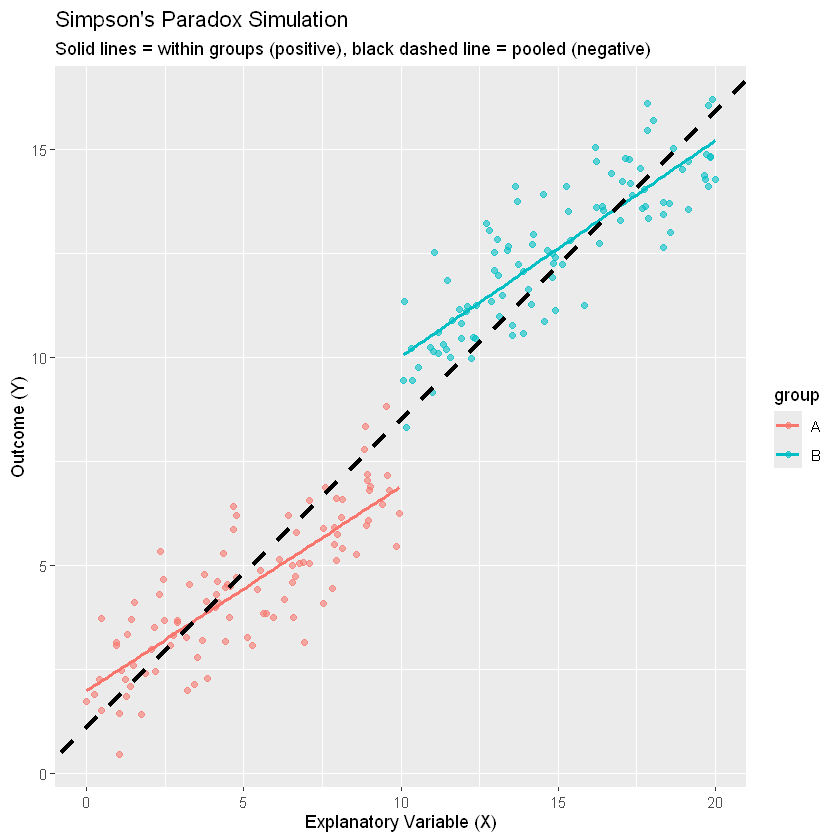

In [2]:
set.seed(123)
library(ggplot2)

# Sample size
n <- 100

# Group A
x_A <- runif(n, 0, 10)
y_A <- 2 + 0.5*x_A + rnorm(n, 0, 1)   # positive relationship
group_A <- data.frame(x = x_A, y = y_A, group = "A")

# Group B
x_B <- runif(n, 10, 20)
y_B <- 5 + 0.5*x_B + rnorm(n, 0, 1)   # also positive
group_B <- data.frame(x = x_B, y = y_B, group = "B")

# Combine data
data <- rbind(group_A, group_B)

# Fit regression models
fit_A <- lm(y ~ x, data = subset(data, group=="A"))
fit_B <- lm(y ~ x, data = subset(data, group=="B"))
fit_all <- lm(y ~ x, data = data)

# Plot
ggplot(data, aes(x=x, y=y, color=group)) +
  geom_point(alpha=0.6) +
  geom_smooth(method="lm", se=FALSE) +  # group-level regression lines
  geom_abline(intercept = coef(fit_all)[1], slope = coef(fit_all)[2],
              color="black", linewidth=1.2, linetype="dashed") +
  labs(title="Simpson's Paradox Simulation",
       subtitle="Solid lines = within groups (positive), black dashed line = pooled (negative)",
       x="Explanatory Variable (X)",
       y="Outcome (Y)")

# Part 2 - Can we omit some controls?

In [ ]:
dag_text <- "
dag {
  Z3 -> Z2
  Z3 -> Y
  Z2 -> X
  Z2 -> Y
  Z1 -> X
  Z1 -> Y
  X  -> Y
}
"

d <- dagitty(dag_text)
coordinates(d) <- list(
  x = c(Z3 = 0, Z2 = 1, Z1 = -1, X = 0, Y = 2),
  y = c(Z3 = 1, Z2 = 0.5, Z1 = 0.5, X = -0.5, Y = 0)
)

plot(d)                # base plot
# or for nicer ggplot-style (optional)
# library(ggdag)
# ggdag::ggdag(d, text = FALSE) + ggtitle("DAG: Z1,Z2,Z3, X -> Y")


`height` was translated to `width`.



Call:
lm(formula = Y ~ X + Z1 + Z2, data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.7543 -0.8135 -0.0113  0.7990  4.7111 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.03146    0.02701   1.165    0.244    
X            1.00176    0.02683  37.337   <2e-16 ***
Z1           1.03319    0.03706  27.880   <2e-16 ***
Z2           1.48738    0.03321  44.781   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 1.206 on 1996 degrees of freedom
Multiple R-squared:  0.9267,	Adjusted R-squared:  0.9266 
F-statistic:  8414 on 3 and 1996 DF,  p-value: < 2.2e-16



Call:
lm(formula = Y ~ X + Z1 + Z2 + Z3, data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.9555 -0.6563 -0.0081  0.6641  3.3655 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.03903    0.02196   1.777   0.0757 .  
X            0.99164    0.02181  45.461   <2e-16 ***
Z1           1.04129    0.03013  34.565   <2e-16 ***
Z2           0.99054    0.03114  31.809   <2e-16 ***
Z3           0.99870    0.03119  32.024   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.9806 on 1995 degrees of freedom
Multiple R-squared:  0.9516,	Adjusted R-squared:  0.9515 
F-statistic:  9806 on 4 and 1995 DF,  p-value: < 2.2e-16


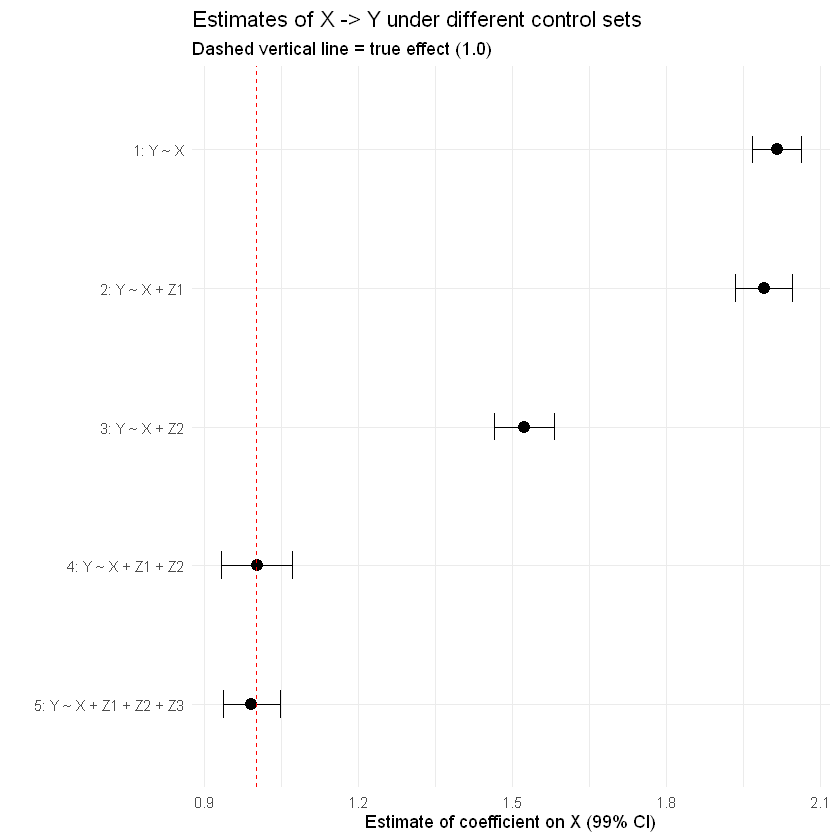

In [4]:
# ---- Simpson-style DAG simulation and regressions ----
set.seed(2025)

# load packages
# install.packages(c("ggplot2","broom","dplyr"))
library(ggplot2)
library(broom)
library(dplyr)

# sample size
N <- 2000

# structural equations (as specified)
eps_Z3 <- rnorm(N, 0, 1)
Z3 <- eps_Z3

eps_Z2 <- rnorm(N, 0, 1)
Z2 <- 1 * Z3 + eps_Z2            # Z3 -> Z2

eps_Z1 <- rnorm(N, 0, 1)
Z1 <- eps_Z1                      # exogenous

eps_X <- rnorm(N, 0, 1)
X <- 1*Z1 + 1*Z2 + eps_X          # Z1 -> X, Z2 -> X

eps_Y <- rnorm(N, 0, 1)
Y <- 1*X + 1*Z1 + 1*Z2 + 1*Z3 + eps_Y  # X->Y and all Z -> Y

data <- data.frame(Y, X, Z1, Z2, Z3)

# Fit regressions:
# (1) Y ~ X
fit1 <- lm(Y ~ X, data = data)

# (2) Y ~ X + Z1
fit2 <- lm(Y ~ X + Z1, data = data)

# (3) Y ~ X + Z2
fit3 <- lm(Y ~ X + Z2, data = data)

# (4) Y ~ X + Z1 + Z2
fit4 <- lm(Y ~ X + Z1 + Z2, data = data)

# (5) Y ~ X + Z1 + Z2 + Z3
fit5 <- lm(Y ~ X + Z1 + Z2 + Z3, data = data)

# function to get point estimate and 99% CI for X
get_est <- function(fit, level = 0.99) {
  cf <- broom::tidy(fit)
  ci <- confint(fit, level = level)
  xrow <- cf %>% filter(term == "X")
  data.frame(
    estimate = xrow$estimate,
    conf.low = ci["X", 1],
    conf.high = ci["X", 2]
  )
}

est1 <- get_est(fit1)
est2 <- get_est(fit2)
est3 <- get_est(fit3)
est4 <- get_est(fit4)
est5 <- get_est(fit5)

ests <- bind_rows(est1, est2, est3, est4, est5)
ests$model <- c("1: Y ~ X",
                "2: Y ~ X + Z1",
                "3: Y ~ X + Z2",
                "4: Y ~ X + Z1 + Z2",
                "5: Y ~ X + Z1 + Z2 + Z3")

# order factor for plotting
ests$model <- factor(ests$model, levels = rev(ests$model))

# Plot estimates with 99% CI (point + errorbar)
ggplot(ests, aes(x = estimate, y = model)) +
  geom_point(size = 3) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0.2) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "red") +
  labs(x = "Estimate of coefficient on X (99% CI)",
       y = "",
       title = "Estimates of X -> Y under different control sets",
       subtitle = "Dashed vertical line = true effect (1.0)") +
  theme_minimal()

summary(fit4)  # regression (4)
summary(fit5)  # regression (5)

- Regressions (4) and (5) provide correct estimates of the causal effect of X on Y, because the estimated coefficient on X is very close to the true effect (1.0) and highly significant. Regressions (1)–(3) are biased because they leave open backdoor paths.
- Interpretation:
    1. In both models, the point estimate for X is essentially equal to the true effect of 1.0.
    2. Adding Z3 does not change the estimate substantially (no bias is introduced), but it does reduce the residual variance and the standard error for X, making the estimate more precise.
- You cannot ignore Z1 or Z2: both are confounders, and leaving either out leads to biased estimates of the effect of X. You can ignore Z3 if the goal is only to obtain an unbiased estimate of the effect of X on Y. This is because controlling for Z1 and Z2 already blocks all backdoor paths. However, including Z3 improves precision since it directly explains variation in Y.

# Part 3 - Damned if you do, damned if you don't 

`height` was translated to `width`.


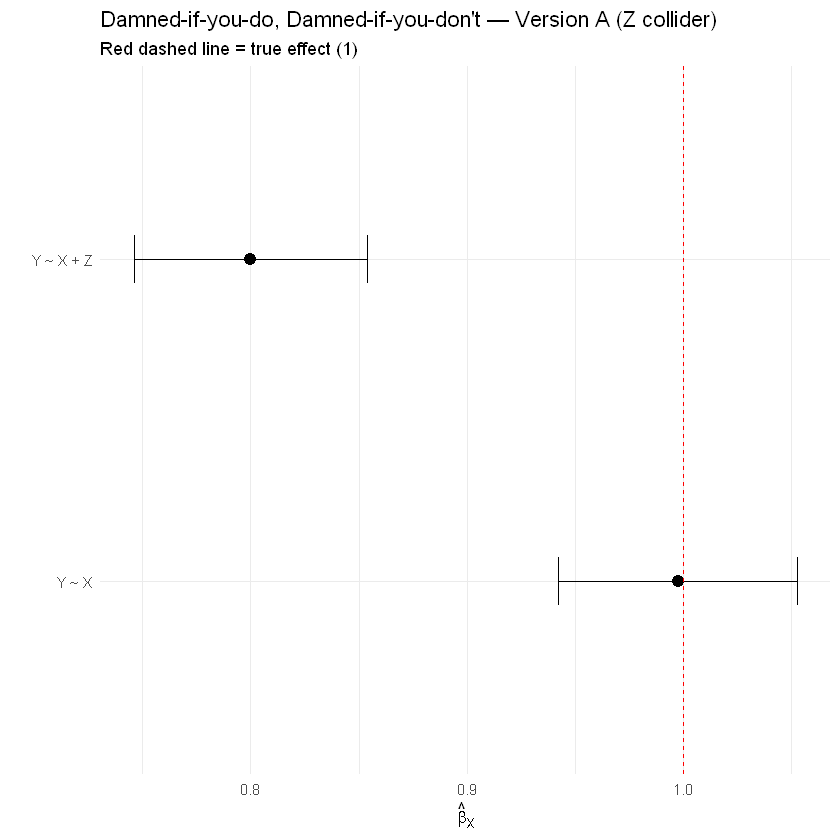

In [5]:
# ---- Version A: Z is a collider (original DAG) ----
set.seed(2025)
library(ggplot2)
library(broom)
library(dplyr)

N <- 2000

# Structural errors
U1 <- rnorm(N,0,1)
U2 <- rnorm(N,0,1)

# Z is collider of U1 and U2
eps_Z <- rnorm(N,0,1)
Z <- 1*U1 + 1*U2 + eps_Z

# X affected by U1 only
eps_X <- rnorm(N,0,1)
X <- 1*U1 + eps_X

# Y affected by X and U2
eps_Y <- rnorm(N,0,1)
Y <- 1*X + 1*U2 + eps_Y

data <- data.frame(Y, X, Z, U1, U2)

# Regressions
fit_noZ <- lm(Y ~ X, data = data)
fit_withZ <- lm(Y ~ X + Z, data = data)

# Extract estimates and 99% CIs
get_est <- function(fit, level = 0.99) {
  cf <- broom::tidy(fit)
  ci <- confint(fit, level = level)
  row <- cf %>% filter(term == "X")
  data.frame(
    model = deparse(formula(fit)),
    estimate = row$estimate,
    se = row$std.error,
    conf.low = ci["X",1],
    conf.high = ci["X",2]
  )
}

estsA <- bind_rows(get_est(fit_noZ), get_est(fit_withZ))
estsA$model <- c("Y ~ X", "Y ~ X + Z")

# Plot estimates with 99% CI and true line at 1
ggplot(estsA, aes(x = estimate, y = model)) +
  geom_point(size = 3) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0.15) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "red") +
  labs(x = expression(hat(beta)[X]),
       y = "",
       title = "Damned-if-you-do, Damned-if-you-don't — Version A (Z collider)",
       subtitle = "Red dashed line = true effect (1)") +
  theme_minimal()


  controls  estimate         se  conf.low conf.high
1     none 1.1398175 0.01246913 1.1153636 1.1642714
2        Z 0.7998521 0.02090172 0.7588607 0.8408436
3       U1 1.3589213 0.01890390 1.3218479 1.3959947
4       U2 0.9965284 0.00972829 0.9774498 1.0156071
5     Z,U1 1.0134047 0.02638315 0.9616633 1.0651461
6     Z,U2 0.9768423 0.01743110 0.9426573 1.0110274
7    U1,U2 1.0109399 0.01730375 0.9770046 1.0448752
8  Z,U1,U2 0.9916379 0.02181277 0.9488597 1.0344161


`height` was translated to `width`.


  controls  estimate         se
1     none 1.1398175 0.01246913
2        Z 0.7998521 0.02090172
3       U1 1.3589213 0.01890390
4       U2 0.9965284 0.00972829
5     Z,U1 1.0134047 0.02638315
6     Z,U2 0.9768423 0.01743110
7    U1,U2 1.0109399 0.01730375
8  Z,U1,U2 0.9916379 0.02181277


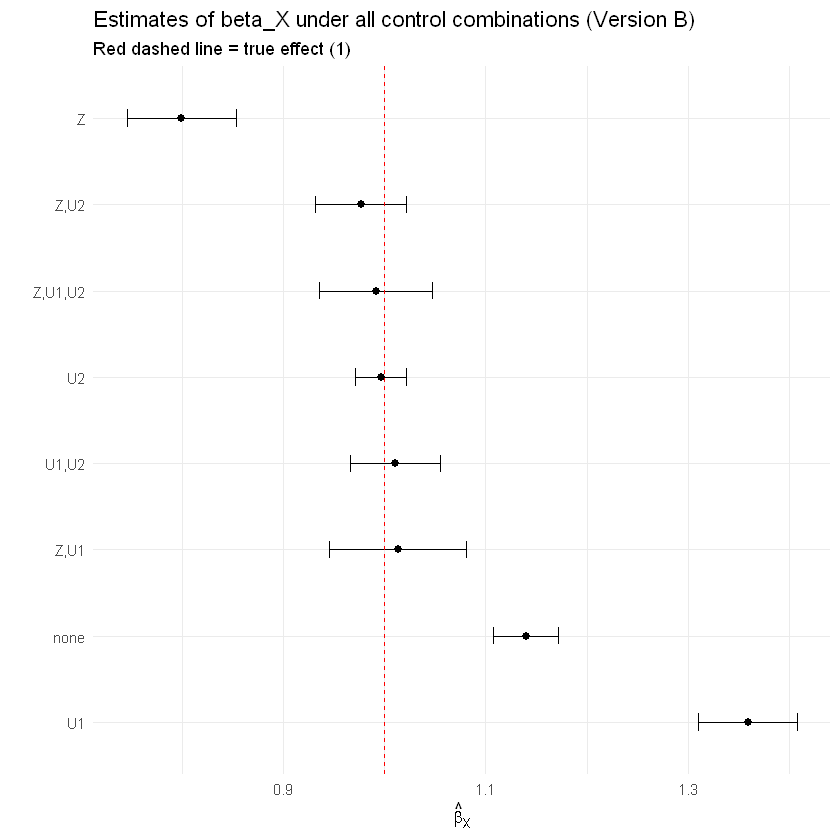

In [7]:
# ---- Version B: Z -> X added (Z affects X). Run all 2^3 regressions ----
set.seed(2025)
library(ggplot2)
library(broom)
library(dplyr)

N <- 2000

# exogenous variables
U1 <- rnorm(N,0,1)
U2 <- rnorm(N,0,1)

# Z is caused by both U1 and U2 (still)
eps_Z <- rnorm(N,0,1)
Z <- 1*U1 + 1*U2 + eps_Z

# Now Z also affects X; X depends on U1 and Z
eps_X <- rnorm(N,0,1)
X <- 1*U1 + 0.8*Z + eps_X   # coefficient 0.8 chosen for illustration

# Y affected by X and U2 (and possibly Z has no direct effect on Y unless you want)
eps_Y <- rnorm(N,0,1)
Y <- 1*X + 1*U2 + eps_Y

data <- data.frame(Y, X, Z, U1, U2)

# All combinations of controls among Z, U1, U2
controls_list <- list(
  c(),            # none
  c("Z"),
  c("U1"),
  c("U2"),
  c("Z","U1"),
  c("Z","U2"),
  c("U1","U2"),
  c("Z","U1","U2")
)

results <- lapply(controls_list, function(ctrls) {
  rhs <- paste(c("X", ctrls), collapse = " + ")
  form <- as.formula(paste("Y ~", rhs))
  fit <- lm(form, data = data)
  cf <- broom::tidy(fit)
  ci <- confint(fit, level = 0.95)  # store 95% CI but SE is enough per pedido
  xrow <- cf %>% filter(term == "X")
  data.frame(
    controls = paste(if(length(ctrls)==0) "none" else ctrls, collapse = ","),
    estimate = xrow$estimate,
    se = xrow$std.error,
    conf.low = ci["X",1],
    conf.high = ci["X",2]
  )
})

results_df <- bind_rows(results)

# Reorder rows in a readable order
results_df <- results_df %>%
  mutate(controls = factor(controls, levels = results_df$controls)) 

# Print results
print(results_df)

# Save table to /output as txt and tex
dir.create("output", showWarnings = FALSE)
# Save as plain text
write.table(results_df %>% select(controls, estimate, se),
            file = "output/beta_se_table.txt",
            sep = "\t", row.names = FALSE, quote = FALSE)

# Save as a simple LaTeX table
tex_lines <- c("\\begin{tabular}{lcc}",
               "\\hline",
               "Controls & $\\beta$ & SE \\\\",
               "\\hline")
for(i in 1:nrow(results_df)) {
  tex_lines <- c(tex_lines,
                 paste0(results_df$controls[i], " & ",
                        sprintf("%.4f", results_df$estimate[i]), " & ",
                        sprintf("%.4f", results_df$se[i]), " \\\\"))
}
tex_lines <- c(tex_lines, "\\hline", "\\end{tabular}")
writeLines(tex_lines, con = "output/beta_se_table.tex")

# Plot the estimates with 99% CI and horizontal true effect at 1
# compute 99% CI from se (approx)
results_df <- results_df %>%
  mutate(conf.low.99 = estimate - 2.5758 * se,
         conf.high.99 = estimate + 2.5758 * se,
         label = controls)

ggplot(results_df, aes(x = estimate, y = reorder(label, -estimate))) +
  geom_point(size = 2) +
  geom_errorbarh(aes(xmin = conf.low.99, xmax = conf.high.99), height = 0.2) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "red") +
  labs(x = expression(hat(beta)[X]),
       y = "",
       title = "Estimates of beta_X under all control combinations (Version B)",
       subtitle = "Red dashed line = true effect (1)") +
  theme_minimal()

# Also print a neat table to console
results_df %>% select(controls, estimate, se) %>% print()



- You can obtain an unbiased estimate of the causal effect of X on Y whenever you block all backdoor paths. This happens when you control for U2 (since U2 → Y opens a confounding path) or when you control for the pair {U1, U2}. Including Z together with either U1 or U2 also works, because those sets block the relevant backdoor paths as well.
- The minimal sufficient set is {U2}. Controlling only for U2 closes the backdoor path 
𝑋←𝑈1→𝑍←𝑈2→𝑌, and thus yields an unbiased estimate close to the true causal effect.
- U2 is a direct confounder because it affects both Z and Y, and indirectly creates a spurious correlation between X and Y through Z. By conditioning on U2, we break this path and recover the true effect of X on Y. More generally, controlling for both U1 and U2 also suffices because together they block every spurious path running through Z. However, Z itself is not a good control alone, since it is a collider between U1 and U2: conditioning on Z can open unwanted paths and induce bias.